# 02 - EDA

Data's validated, so now I'm looking at what's actually going on in it — how often people
order, what they buy again, which categories drive volume, and when orders tend to happen.
These patterns are what the baseline models in the next notebook will lean on, so the goal
here is to understand the signal before picking an approach, not just make charts.

Logic in `src/eda.py`.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt

from data_processing import load_raw_data, save_processed
from eda import (
    build_transactions, customer_behavior, product_behavior,
    reorder_behavior, basket_analysis, time_behavior
)

plt.rcParams['figure.figsize'] = (10, 4)

## Transactions table

Everything below is built off this one flat table — order_products joined with orders and
products/aisles/departments. Saving it to parquet so I'm not re-joining ~34M rows every time
I open a new notebook.

In [2]:
data = load_raw_data()
txn = build_transactions(data)
print(txn.shape)
txn.head()

(33819106, 15)


,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,202279,prior,3,5,9,8.0,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,202279,prior,3,5,9,8.0,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,202279,prior,3,5,9,8.0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,202279,prior,3,5,9,8.0,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,202279,prior,3,5,9,8.0,Natural Sweetener,17,13,baking ingredients,pantry


In [3]:
save_processed(txn, "transactions")

WindowsPath('D:/Documents/Internship/DecodeLabs/Project-3   30-07-2026/quick-commerce-recommender/data/processed/transactions.parquet')

## Customer behavior

Looking at order frequency, basket size, and reorder rate per user. Restricted to
eval_set = 'prior' since that's actual purchase history.

             user_id       n_orders  avg_basket_size  avg_days_between_orders  \
count  206209.000000  206209.000000    206209.000000            206209.000000   
mean   103105.000000      15.590367         9.951586                15.469669   
std     59527.555167      16.654774         5.863570                 7.207436   
min         1.000000       3.000000         1.000000                 0.000000   
25%     51553.000000       5.000000         5.740741                 9.553798   
50%    103105.000000       9.000000         8.933333                14.692307   
75%    154657.000000      19.000000        13.000000                20.724409   
max    206209.000000      99.000000        70.250000                30.000000   

        reorder_rate  
count  206209.000000  
mean        0.432249  
std         0.212144  
min         0.000000  
25%         0.267857  
50%         0.428571  
75%         0.595745  
max         0.989529  


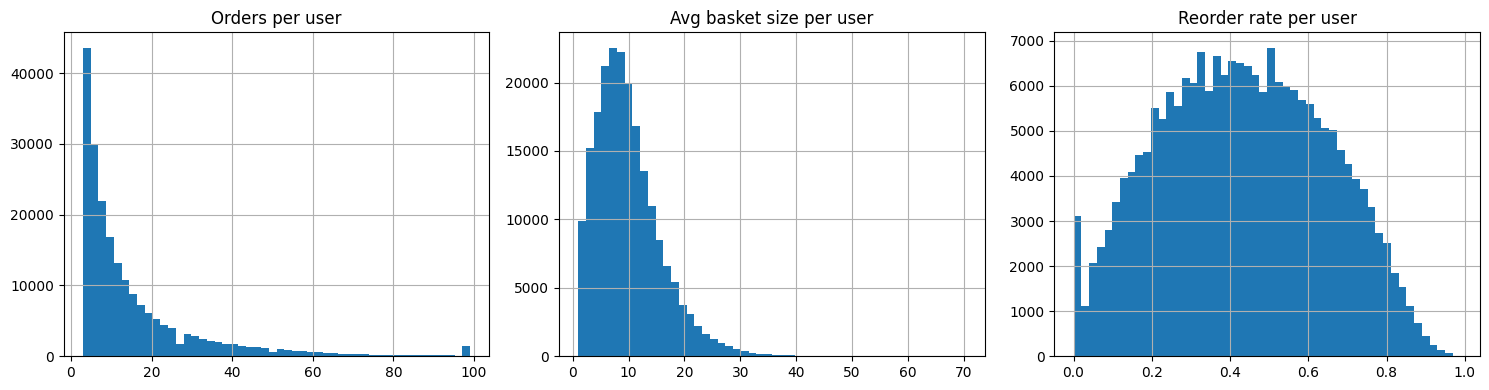

In [4]:
cb = customer_behavior(txn)
print(cb.describe())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cb["n_orders"].hist(bins=50, ax=axes[0]); axes[0].set_title("Orders per user")
cb["avg_basket_size"].hist(bins=50, ax=axes[1]); axes[1].set_title("Avg basket size per user")
cb["reorder_rate"].hist(bins=50, ax=axes[2]); axes[2].set_title("Reorder rate per user")
plt.tight_layout(); plt.show()

## Product behavior

Which products get bought the most, and which get *rebought* the most — these aren't
always the same list, and the gap between them matters for the popularity baseline.

In [5]:
pb = product_behavior(txn)
pb.head(15)

,product_id,product_name,aisle,department,n_purchases,n_unique_users,reorder_rate,avg_add_to_cart_position
24848,24852,Banana,fresh fruits,produce,472565,73956,0.843501,4.894129
13172,13176,Bag of Organic Bananas,fresh fruits,produce,379450,63537,0.832555,5.095947
21133,21137,Organic Strawberries,fresh fruits,produce,264683,58838,0.777704,7.248902
21899,21903,Organic Baby Spinach,packaged vegetables fruits,produce,241921,55037,0.772500,7.429640
47198,47209,Organic Hass Avocado,fresh fruits,produce,213584,43453,0.796553,6.775011
47755,47766,Organic Avocado,fresh fruits,produce,176815,42771,0.758103,6.444617
47615,47626,Large Lemon,fresh fruits,produce,152657,46402,0.696038,7.948617
16793,16797,Strawberries,fresh fruits,produce,142951,43149,0.698155,7.116096
26204,26209,Limes,fresh fruits,produce,140627,44859,0.681007,8.581823
27839,27845,Organic Whole Milk,milk,dairy eggs,137905,23395,0.830354,5.434749


In [7]:
# filtering to products with meaningful volume so low-count noise doesn't
# dominate the reorder-rate ranking
pb[pb["n_purchases"] >= 100].sort_values("reorder_rate", ascending=False).head(15)

,product_id,product_name,aisle,department,n_purchases,n_unique_users,reorder_rate,avg_add_to_cart_position
27734,27740,Chocolate Love Bar,candy chocolate,snacks,101,8,0.920792,3.702970
35598,35604,Maca Buttercups,candy chocolate,snacks,100,10,0.900000,4.570000
38243,38251,Benchbreak Chardonnay,white wines,alcohol,111,12,0.891892,2.603604
10232,10236,Fragrance Free Clay with Natural Odor Eliminat...,cat food care,pets,129,16,0.875969,6.131783
20594,20598,Thousand Island Salad Snax,fruit vegetable snacks,snacks,112,14,0.875000,3.151786
35490,35496,Real2 Alkalized Water 500 ml,water seltzer sparkling water,beverages,451,62,0.862528,5.432373
9288,9292,Half And Half Ultra Pasteurized,milk,dairy eggs,2921,404,0.861691,3.835673
45495,45504,Whole Organic Omega 3 Milk,milk,dairy eggs,9108,1273,0.860233,5.268226
43386,43394,Organic Lactose Free Whole Milk,soy lactosefree,dairy eggs,8477,1195,0.859030,4.850537
5511,5514,Organic Homogenized Whole Milk,milk,dairy eggs,3970,565,0.857683,4.770529


## Reorder behavior

Overall reorder rate, and whether it varies meaningfully by department or by how many
orders a user has already placed.

overall reorder rate: 0.59


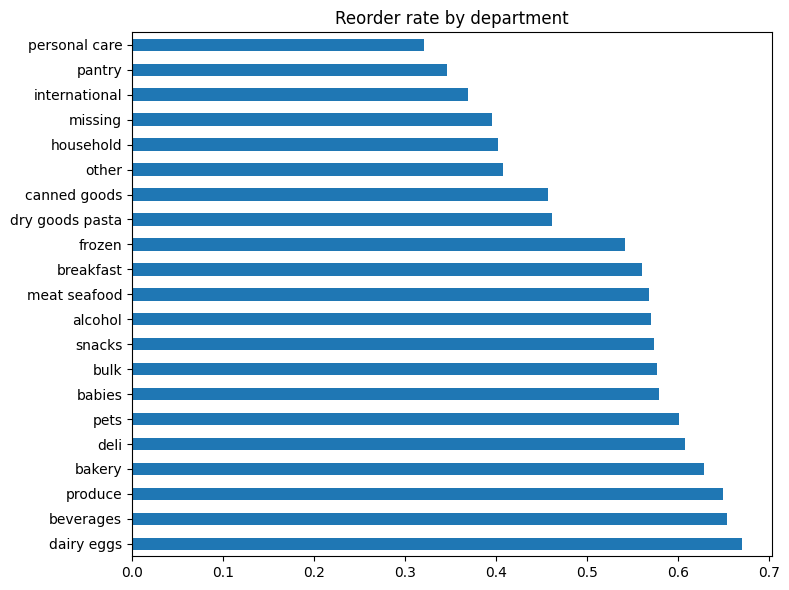

In [8]:
rb = reorder_behavior(txn)
print("overall reorder rate:", round(rb["overall_reorder_rate"], 3))

pd.Series(rb["reorder_rate_by_department"]).plot(kind="barh", figsize=(8,6), title="Reorder rate by department")
plt.tight_layout(); plt.show()

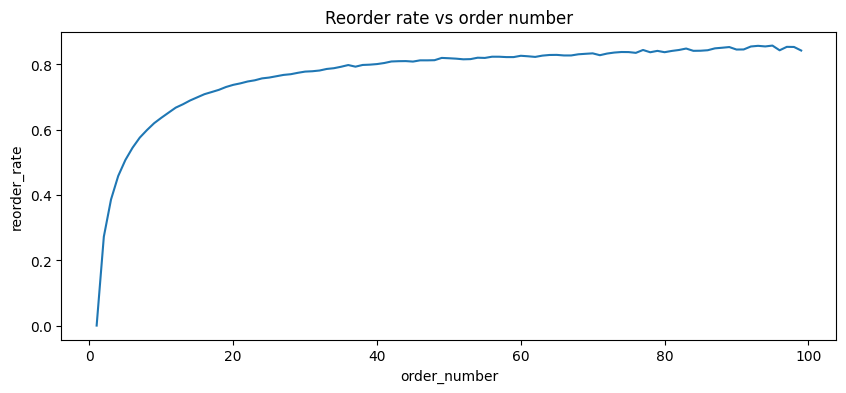

In [9]:
pd.Series(rb["reorder_rate_by_order_number"]).sort_index().plot(
    title="Reorder rate vs order number"
)
plt.xlabel("order_number"); plt.ylabel("reorder_rate"); plt.show()

## Basket analysis

How big is a typical basket, and which departments/aisles account for most of the volume.

In [10]:
ba = basket_analysis(txn)
print("basket size:", ba["basket_size_summary"])
print("top departments:", ba["top_departments_by_volume"])
print("top aisles:", ba["top_aisles_by_volume"])

basket size: {'count': 3214874.0, 'mean': 10.088883421247614, 'std': 7.525398340046085, 'min': 1.0, '25%': 5.0, '50%': 8.0, '75%': 14.0, 'max': 145.0}
top departments: {'produce': 9479291, 'dairy eggs': 5414016, 'snacks': 2887550, 'beverages': 2690129, 'frozen': 2236432, 'pantry': 1875577, 'bakery': 1176787, 'canned goods': 1068058, 'deli': 1051249, 'dry goods pasta': 866627}
top aisles: {'fresh fruits': 3642188, 'fresh vegetables': 3418021, 'packaged vegetables fruits': 1765313, 'yogurt': 1452343, 'packaged cheese': 979763, 'milk': 891015, 'water seltzer sparkling water': 841533, 'chips pretzels': 722470, 'soy lactosefree': 638253, 'bread': 584834}


## Time behavior

When orders actually happen — useful later for the app/business-impact side of the
project (e.g. staffing or inventory decisions around peak windows), not just modeling.

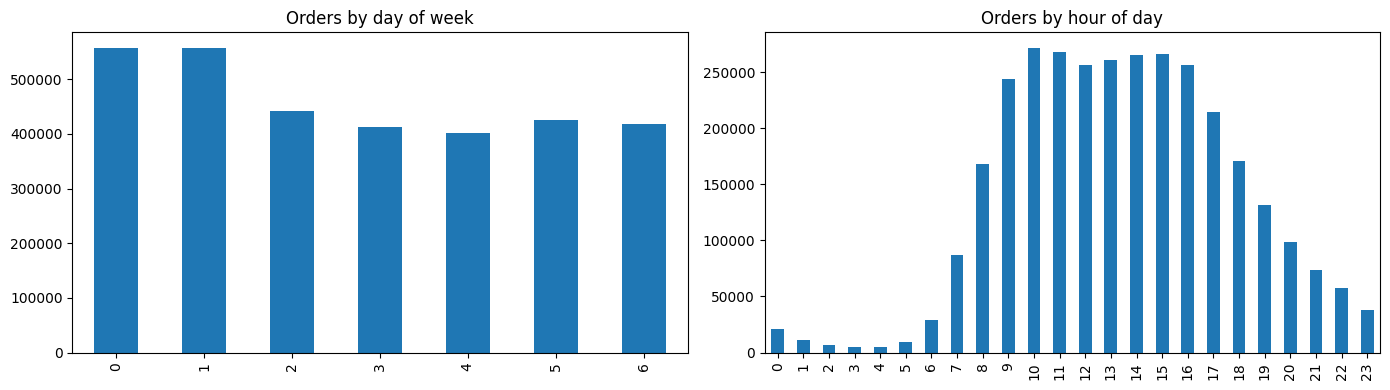

In [11]:
tb = time_behavior(txn)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
pd.Series(tb["orders_by_dow"]).sort_index().plot(kind="bar", ax=axes[0], title="Orders by day of week")
pd.Series(tb["orders_by_hour"]).sort_index().plot(kind="bar", ax=axes[1], title="Orders by hour of day")
plt.tight_layout(); plt.show()

### Key EDA Findings & Implications

### Notes

The EDA highlights several behavioral signals that should inform the recommendation baselines:

* **Strong repeat-purchase behavior:** The overall reorder rate is approximately **59%**, indicating that repeat purchasing is a substantial component of customer behavior and should be incorporated into the baseline strategy.

* **Meaningful customer-level variation:** Across 206,209 users, the average customer places approximately **15.6 orders**, with a median of **9 orders**. The average basket size per customer is approximately **10 items**, while the median is approximately **8.9 items**. Customer reorder rates also vary considerably, suggesting that purchase history and individual reorder propensity can provide useful recommendation signals.

* **Product popularity and reordering are distinct signals:** The most frequently purchased products are dominated by fresh produce, including **Bananas, Organic Bananas, Organic Strawberries, Organic Baby Spinach, and avocados**. However, the products with the highest reorder rates are not necessarily the most popular products. This supports evaluating both **global popularity** and **historical reorder propensity** as separate baseline signals.

* **High-reorder products:** Several products exhibit reorder rates above **85%**, particularly within categories such as dairy and eggs, beverages, and other frequently repurchased consumer products. These products may provide strong candidates for a reorder-oriented recommendation baseline, subject to sufficient purchase volume.

* **Basket size:** The analysis covers approximately **3.21M baskets**, with an average basket size of **10.1 items** and a median of **8 items**. The distribution is right-skewed, with some baskets containing substantially more items, so median basket size may be more representative of typical customer behavior than the mean.

* **Category concentration:** **Produce** is the largest department by purchase volume, followed by **dairy & eggs, snacks, beverages, and frozen**. At the aisle level, **fresh fruits, fresh vegetables, packaged vegetables/fruits, yogurt, and packaged cheese** contribute the greatest volume. This concentration should be considered when interpreting popularity-based recommendations.

* **Recommendation implication:** Given the strong overall reorder signal and the distinction between product popularity and reorder propensity, Baseline model should establish baselines that capture both **popular-item recommendations** and **customer-specific repeat-purchase behavior**, providing a meaningful benchmark for subsequent recommendation approaches.
